### Importación de librerías necesárias

In [76]:
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import json

import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV


### Summary
1. Load processed data
2. Define X / y
3. Train-validation-test split
4. Define baseline pipelines
5. Train models
6. Validation evaluation
7. Compare models
8. Analyze important features / shortcuts
9. Select final model
10. Final evaluation on test
11. Save artifacts
12. Load artifact
13. Test inference with unseen example

### Importando el dataset preprocesado

In [ ]:
df = pd.read_csv("../Data/ml/processed_data_en.csv")


In [4]:
print(df.shape)
df.head()

(5828, 4)


,title,text,content,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,A whole lot of evangelical Trump voters just d...,WATCH: Trump Just Told All The Anti-Gay Bigots...,0
1,"China backs U.N. call for justice in Yemen, U....",GENEVA (Reuters) - China signaled on Wednesday...,"China backs U.N. call for justice in Yemen, U....",1
2,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,0
3,Lawmakers aim to delay U.S. ceding control of ...,WASHINGTON (Reuters) - Critics of a plan for t...,Lawmakers aim to delay U.S. ceding control of ...,1
4,"Trump STRANDED, In Full Panic As ANOTHER Perf...",President-elect Donald Trump has had trouble f...,"Trump STRANDED, In Full Panic As ANOTHER Perfo...",0


### Modelado

##### Definiendo X e Y

In [5]:
X = df["content"]
y = df["label"]

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

#### Distribucion en train/validation y test

In [13]:
print(
    "Train distribution:"
)
print(y_train.value_counts(normalize=True))

print(
    "\nValidation distribution:"
)
print(y_val.value_counts(normalize=True))

print(
    "\nTest distribution:"
)
print(y_test.value_counts(normalize=True))

Train distribution:
label
1    0.513851
0    0.486149
Name: proportion, dtype: float64

Validation distribution:
label
1    0.51373
0    0.48627
Name: proportion, dtype: float64

Test distribution:
label
1    0.514286
0    0.485714
Name: proportion, dtype: float64


#### Definiendo los parámetros necesários para TF-IDF

In [14]:
tfidf_params = {
    "lowercase": True,
    "stop_words": "english",
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
    "max_features": 30000
}

#### Pipelines candidatos

In [15]:
pipelines = {
    "Logistic Regression": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(**tfidf_params)
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]),

    "Linear SVM": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(**tfidf_params)
        ),
        (
            "classifier",
            LinearSVC(
                random_state=42
            )
        )
    ]),

    "Multinomial NB": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(**tfidf_params)
        ),
        (
            "classifier",
            MultinomialNB()
        )
    ])
}

#### Función de evaluación

In [17]:
def evaluate_model(
    model,
    X_eval,
    y_eval
):
    y_pred = model.predict(X_eval)

    return {
        "accuracy": accuracy_score(
            y_eval,
            y_pred
        ),
        "precision_macro": precision_score(
            y_eval,
            y_pred,
            average="macro"
        ),
        "recall_macro": recall_score(
            y_eval,
            y_pred,
            average="macro"
        ),
        "f1_macro": f1_score(
            y_eval,
            y_pred,
            average="macro"
        )
    }

In [19]:
results = []

trained_models = {}

for name, pipeline in pipelines.items():

    print(f"Training: {name}")

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[name] = pipeline

    metrics = evaluate_model(
        pipeline,
        X_val,
        y_val
    )

    metrics["model"] = name

    results.append(metrics)

Training: Logistic Regression
Training: Linear SVM
Training: Multinomial NB


In [20]:
results_df = (
    pd.DataFrame(results)
    .set_index("model")
    .sort_values(
        "f1_macro",
        ascending=False
    )
)

display(results_df)

,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
Linear SVM,0.986270,0.986813,0.985945,0.986249
Logistic Regression,0.978261,0.979242,0.977773,0.978217
Multinomial NB,0.943936,0.944179,0.943674,0.943865


F1 Macro nos da el resumen medio, pero queremos saber en cada clase:

In [23]:
for name in [
    "Linear SVM",
    "Logistic Regression"
]:
    model = trained_models[name]

    y_val_pred = model.predict(X_val)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_val,
            y_val_pred,
            target_names=["Fake", "Actual"],
            digits=4
        )
    )

Linear SVM
              precision    recall  f1-score   support

        Fake     0.9976    0.9741    0.9857       425
      Actual     0.9760    0.9978    0.9868       449

    accuracy                         0.9863       874
   macro avg     0.9868    0.9859    0.9862       874
weighted avg     0.9865    0.9863    0.9863       874

Logistic Regression
              precision    recall  f1-score   support

        Fake     0.9951    0.9600    0.9772       425
      Actual     0.9634    0.9955    0.9792       449

    accuracy                         0.9783       874
   macro avg     0.9792    0.9778    0.9782       874
weighted avg     0.9788    0.9783    0.9782       874



#### Matriz de confusión

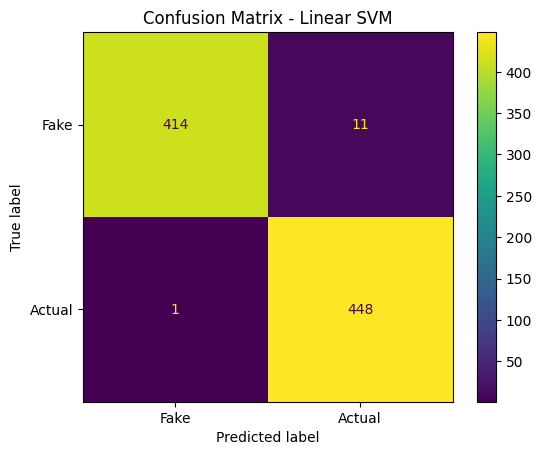

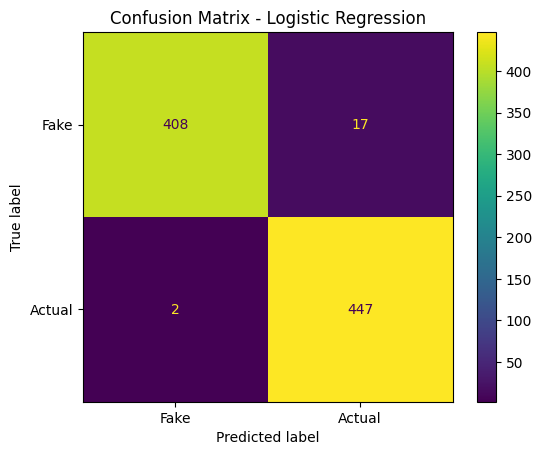

In [25]:
for name in [
    "Linear SVM",
    "Logistic Regression"
]:
    model = trained_models[name]

    y_val_pred = model.predict(X_val)

    ConfusionMatrixDisplay.from_predictions(
        y_val,
        y_val_pred,
        display_labels=["Fake", "Actual"],
        values_format="d"
    )

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.show()

In [33]:
def get_top_features(
    pipeline,
    top_n=20
):
    vectorizer = pipeline.named_steps["tfidf"]
    classifier = pipeline.named_steps["classifier"]

    feature_names = (
        vectorizer.get_feature_names_out()
    )

    coefficients = (
        classifier.coef_[0]
    )

    top_actual_idx = (
        coefficients
        .argsort()[-top_n:][::-1]
    )

    top_fake_idx = (
        coefficients
        .argsort()[:top_n]
    )

    top_actual = pd.DataFrame({
        "feature": feature_names[
            top_actual_idx
        ],
        "coefficient": coefficients[
            top_actual_idx
        ]
    })

    top_fake = pd.DataFrame({
        "feature": feature_names[
            top_fake_idx
        ],
        "coefficient": coefficients[
            top_fake_idx
        ]
    })

    return top_fake, top_actual

In [34]:
svm_top_fake, svm_top_actual = (
    get_top_features(
        trained_models["Linear SVM"]
    )
)

display(svm_top_fake)
display(svm_top_actual)

,feature,coefficient
0,video,-2.317109
1,just,-1.717301
2,gop,-1.672110
3,president trump,-1.623776
4,hillary,-1.583791
5,read,-1.535056
6,america,-1.522713
7,featured,-1.447783
8,featured image,-1.397810
9,mr,-1.375631


,feature,coefficient
0,reuters,6.174425
1,said,4.890772
2,washington reuters,2.573095
3,president donald,1.717998
4,tuesday,1.492621
5,thursday,1.424042
6,washington,1.313820
7,wednesday,1.260577
8,republican,1.233794
9,reuters president,1.226817


In [35]:
lr_top_fake, lr_top_actual = (
    get_top_features(
        trained_models[
            "Logistic Regression"
        ]
    )
)

display(lr_top_fake)
display(lr_top_actual)

,feature,coefficient
0,video,-4.323101
1,just,-3.094572
2,hillary,-3.055382
3,like,-2.585847
4,america,-2.362580
5,gop,-2.349236
6,image,-2.278659
7,featured,-2.185825
8,watch,-2.183616
9,featured image,-2.140583


,feature,coefficient
0,said,8.776450
1,reuters,7.249583
2,washington reuters,3.273632
3,washington,2.365492
4,thursday,2.266623
5,tuesday,2.204993
6,president donald,2.140293
7,wednesday,2.133648
8,republican,2.041515
9,minister,2.039404


Dentro de este dataset, la presencia de `Reuters` aporta una señal muy fuerte hacia la clase Actual. Lo que el modelo ha aprendido es que en los datos de entrenamiento `Reuters` está fuertemente asociado a la clase Actual (label 1), esto confirma la evidencia encontrada en la fase EDA. Pero debemos seguir analizando. 

La mayorías de las features no son características relacionadas con que una afirmación sea verdadera, son características relacionadas con estilo periodístico / formato de agencia / procedencia.

Los dos modelos lineales presentan entre sus características con mayor peso hacia la clase Actual términos como reuters, said, washington reuters, nombres de días de la semana y términos asociados al estilo periodístico de agencia. Este resultado es coherente con los patrones identificados durante el EDA y confirma que el alto rendimiento del clasificador está parcialmente relacionado con señales de procedencia y estilo editorial. Por tanto, las métricas obtenidas no deben interpretarse directamente como capacidad general de detección de veracidad.

Linear SVM es el mejor clasificador baseline en validación, con un Macro-F1 de 0,9862 y únicamente 12 errores sobre 874 observaciones. Logistic Regression obtiene también un rendimiento muy elevado, pero comete 19 errores. Sin embargo, el análisis de coeficientes muestra que ambos modelos asignan gran peso a términos asociados a Reuters y al estilo periodístico de agencia, lo que confirma los shortcuts detectados en el EDA. Por ello, el rendimiento elevado debe interpretarse como capacidad de clasificación dentro de este corpus, no como evidencia de capacidad general.

12 Errores cometidos por SVM: <br>

Queremos comprobar si las clases predichas como `Real` cuando deberían ser `Fake` contienen el shortcut `Reuters`, `Said`... por ejemplo.

In [36]:
svm_model = trained_models["Linear SVM"]

svm_val_pred = svm_model.predict(X_val)

errors_svm = pd.DataFrame({
    "content": X_val,
    "true_label": y_val,
    "predicted_label": svm_val_pred
})

errors_svm = errors_svm[
    errors_svm["true_label"]
    != errors_svm["predicted_label"]
].copy()

print(
    "SVM validation errors:",
    len(errors_svm)
)

display(errors_svm)

SVM validation errors: 12


,content,true_label,predicted_label
2680,HERE’S THIS LIST OF REPUBLICANS Running For Re...,0,1
3598,"In court first, Swede jailed for rape of child...",1,0
4839,WHOA! Brand New Poll Finds Trump Taking YUGE L...,0,1
3294,POLL SHOWS WHICH Candidate Will Benefit Most F...,0,1
1449,Republicans Just Changed The Rules To Force Th...,0,1
3550,TRUMP TELLS State Department To Make CUT More ...,0,1
2032,JUST IN: TRUMP ENDS FREE MONEY TRAIN After Pak...,0,1
5028,ISRAEL WILL NAME New Train Station Near Wester...,0,1
4244,“THE WAR ON COAL IS OVER”…First New Coal Mine ...,0,1
3284,BREAKING: 4 AMERICAN HOSTAGES TAKEN BY IRAN-BA...,0,1


In [38]:
pd.set_option('display.max_colwidth',1000)

In [39]:
errors_svm["true_class"] = (
    errors_svm["true_label"]
    .map({
        0: "Fake",
        1: "Actual"
    })
)

errors_svm["predicted_class"] = (
    errors_svm["predicted_label"]
    .map({
        0: "Fake",
        1: "Actual"
    })
)

display(
    errors_svm[
        [
            "true_class",
            "predicted_class",
            "content"
        ]
    ]
)

,true_class,predicted_class,content
2680,Fake,Actual,"HERE’S THIS LIST OF REPUBLICANS Running For Re-election In 2016 Who Won’t Support Trump. Here is the list of Republicans who won t support Trump. The candidates highlighted in blue are in close races in their states.Hmmm .I wonder how many of these politicians wouldn t be in close races today if they had endorsed Trump? Kelly Ayotte, Senator of New Hampshire Robert Bentley, Governor of Alabama Jaime Herrera Beutler, Representative of Washington Bradley Byrne, Representative of Alabama Jason Chaffetz, Representative of Utah Mike Coffman, Representative of Colorado Barbara Comstock, Representative of Virginia Michael D. Crapo, Senator of Idaho Dennis Daugaard, Governor of South Dakota Rodney Davis, Representative of Illinois Deb Fischer, Senator of Nebraska Jeff Flake, Senator of Arizona Jeff Fortenberry, Representative of Nebraska Darryl Glenn, Running for Senate from Colorado Cory Gardner, Senator of Colorado Scott Garrett, Representative of New Jersey Kay Granger, Representative o..."
3598,Actual,Fake,"In court first, Swede jailed for rape of children online. STOCKHOLM (Reuters) - A man was jailed for 10 years for rape by a Swedish court on Thursday for forcing 27 children from the United States, Canada and Britain to perform sex acts on themselves or with other children that he viewed over the internet. The case, heard in Uppsala, marked the first time in Sweden that a person has been convicted of rape without having met the victim - setting a precedent for such crimes over the internet to be treated as seriously as if they were committed in person. The district court makes a very important assessment here. It states clearly what is required for an act performed by a girl on her own body to be regarded as rape when the perpetrator is not in the same room, prosecutor Annika Wennerstrom told TT news agency. This may lead to a different level of priority and status from the police in criminal investigations with these types of crimes. The 41-year-old Swede found the girls via socia..."
4839,Fake,Actual,"WHOA! Brand New Poll Finds Trump Taking YUGE Lead Over Crooked Hillary. Trump landslide in 5 4 3 2 1A new poll shows that Donald Trump has vastly improved his support among voters since becoming the presumptive Republican nominee. The Washington Post/ABC poll released Saturday night shows that Trump is now favored by 46 percent among registered voters, with Clinton at 44 percent.That marks an eleven-point shift towards Trump since the same poll conducted in March. Clinton is down five points among registered voters while Trump is up six.Forty-four percent of voters said they wanted a third-party candidate to run, but 51 percent said they were satisfied with the current field.When asked to pick Clinton, Trump, or Romney, only 22 percent of voters chose the former failed Republican nominee, while 37 percent chose Clinton and 35 percent chose Trump.The poll was conducted May 16-19 of 1,005 adults (829 registered voters) with a margin of error of plus or minus 3.5 percentage points. Vi..."
3294,Fake,Actual,"POLL SHOWS WHICH Candidate Will Benefit Most From Rubio’s Exit. If Rubio would have dropped out a month ago, we might have a very different outcome today Marco Rubio s loss is Ted Cruz s gain, a new poll shows.The Texas senator will benefit most from Rubio s exit from the presidential race, according to new Morning Consult polling.Among 412 Rubio supporters polled, 47 percent support Cruz as a second choice.Twenty-seven percent of respondents said they would back Ohio Gov. John Kasich if Rubio dropped out and only 13 percent of Rubio backers said they d support front-runner Donald Trump.Nine percent said they d vote for someone else and 5 percent don t know.Morning Consult interviewed 8,732 registered voters from March 11 to 15, including 3,372 Republicans and Republican-leaning independents. Via: NY Post"
1449,Fake,Actual,"Republicans Just Changed The Rules To Force Through T

In [40]:
errors_svm["contains_reuters"] = (
    errors_svm["content"]
    .str.contains(
        r"\breuters\b",
        case=False,
        regex=True
    )
)

pd.crosstab(
    errors_svm["true_class"],
    errors_svm["contains_reuters"]
)

contains_reuters,False,True
true_class,,
Actual,0,1
Fake,11,0


Los 11 Fake que confunde con Actual NO contienen Reuters, es decir, Reuters es una señal muy potente globalmente, pero no es una regla determinista del modelo.

Aunque Reuters presenta uno de los coeficientes más elevados hacia la clase Actual, no actúa como una regla determinista. Ninguna de las 11 noticias Fake clasificadas erróneamente como Actual contiene el término Reuters, mientras que la única noticia Actual clasificada como Fake sí lo contiene. Esto indica que la decisión del modelo depende de la combinación de múltiples características léxicas y estilísticas, y no únicamente de un marcador de fuente concreto.

Otras comprobaciones: <br>

¿Aparecen en los Fake mal clasificados varios marcadores que sabemos que empujan hacia Actual?

In [41]:
actual_markers = [
    "said",
    "washington",
    "tuesday",
    "wednesday",
    "thursday",
    "monday",
    "republican",
    "spokesman",
    "minister",
    "reporters"
]

fake_as_actual = errors_svm[
    (errors_svm["true_label"] == 0)
    & (errors_svm["predicted_label"] == 1)
].copy()

marker_counts = {}

for marker in actual_markers:
    marker_counts[marker] = (
        fake_as_actual["content"]
        .str.contains(
            rf"\b{marker}\b",
            case=False,
            regex=True
        )
        .sum()
    )

pd.Series(
    marker_counts
).sort_values(ascending=False)

said          10
republican     4
washington     2
tuesday        2
thursday       2
wednesday      2
monday         2
spokesman      1
minister       1
reporters      1
dtype: int64

#### Tuning del modelo:

SVM

In [43]:
svm_param_grid = {
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],
    "tfidf__min_df": [
        2,
        5
    ],
    "tfidf__max_features": [
        20000,
        30000
    ],
    "classifier__C": [
        0.5,
        1,
        2
    ]
}

In [44]:
svm_grid = GridSearchCV(
    estimator=pipelines["Linear SVM"],
    param_grid=svm_param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__C': [0.5, 1, ...], 'tfidf__max_features': [20000, 30000], 'tfidf__min_df': [2, 5], 'tfidf__ngram_range': [(1, ...), (1, ...)]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [45]:
print(
    "Best SVM params:",
    svm_grid.best_params_
)

print(
    "Best CV Macro-F1:",
    svm_grid.best_score_
)

Best SVM params: {'classifier__C': 2, 'tfidf__max_features': 20000, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Best CV Macro-F1: 0.9796254341941795


Logistic Regression

In [46]:
lr_param_grid = {
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],
    "tfidf__min_df": [
        2,
        5
    ],
    "tfidf__max_features": [
        20000,
        30000
    ],
    "classifier__C": [
        0.5,
        1,
        2,
        5
    ]
}

In [47]:
lr_grid = GridSearchCV(
    estimator=pipelines[
        "Logistic Regression"
    ],
    param_grid=lr_param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__C': [0.5, 1, ...], 'tfidf__max_features': [20000, 30000], 'tfidf__min_df': [2, 5], 'tfidf__ngram_range': [(1, ...), (1, ...)]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [48]:
print(
    "Best LR params:",
    lr_grid.best_params_
)

print(
    "Best CV Macro-F1:",
    lr_grid.best_score_
)

Best LR params: {'classifier__C': 5, 'tfidf__max_features': 30000, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Best CV Macro-F1: 0.9744645076376374


In [50]:
best_svm = svm_grid.best_estimator_
best_lr = lr_grid.best_estimator_

Evaluation Models:

In [51]:
tuned_results = []

for name, model in {
    "Tuned Linear SVM": best_svm,
    "Tuned Logistic Regression": best_lr
}.items():

    metrics = evaluate_model(
        model,
        X_val,
        y_val
    )

    metrics["model"] = name
    tuned_results.append(metrics)

tuned_results_df = (
    pd.DataFrame(tuned_results)
    .set_index("model")
)

display(tuned_results_df)

,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
Tuned Linear SVM,0.987414,0.987881,0.987122,0.987396
Tuned Logistic Regression,0.981693,0.982394,0.981302,0.981662


In [52]:
display(results_df)

,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
Linear SVM,0.986270,0.986813,0.985945,0.986249
Logistic Regression,0.978261,0.979242,0.977773,0.978217
Multinomial NB,0.943936,0.944179,0.943674,0.943865


El ajuste de hiperparámetros produjo mejoras moderadas, sin alterar el ranking observado entre los modelos base.

El ajuste de hiperparámetros mejora ligeramente el rendimiento de ambos clasificadores sin modificar el ranking observado inicialmente. Linear SVM alcanza un Macro-F1 de 0,9874 sobre validación frente a 0,9862 en su configuración base, mientras que Logistic Regression mejora de 0,9782 a 0,9817. Linear SVM continúa siendo, por tanto, el principal candidato. Ambos modelos seleccionan representaciones TF-IDF con unigramas y bigramas y min_df=5, indicando que la inclusión de contexto léxico breve y la exclusión de términos extremadamente infrecuentes favorecen el rendimiento. Dado el elevado rendimiento observado y los shortcuts identificados previamente, antes de seleccionar el modelo final se realizará un experimento de sensibilidad eliminando el marcador explícito de fuente Reuters.

¿Cuánto de ese 98,7% para el SVM, depende de los shortcuts de procedencia y estilo?

1 - Eliminar Reuters

In [55]:
def remove_reuters(text):
    return re.sub(
        r"\breuters\b",
        " ",
        str(text),
        flags=re.IGNORECASE
    )

In [56]:
X_train_no_reuters = X_train.apply(
    remove_reuters
)

X_val_no_reuters = X_val.apply(
    remove_reuters
)

In [57]:
svm_no_reuters = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=5,
            max_df=0.95,
            max_features=20000
        )
    ),
    (
        "classifier",
        LinearSVC(
            C=2,
            random_state=42
        )
    )
])

In [58]:
svm_no_reuters.fit(
    X_train_no_reuters,
    y_train
)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [59]:
no_reuters_metrics = evaluate_model(
    svm_no_reuters,
    X_val_no_reuters,
    y_val
)

no_reuters_metrics

{'accuracy': 0.9805491990846682,
 'precision_macro': 0.9815391084945333,
 'recall_macro': 0.9800628848421329,
 'f1_macro': 0.9805103921401447}

Comparando SVM con y sin Reuters:

In [60]:
ablation_results = pd.DataFrame([
    {
        "experiment": "Original",
        **evaluate_model(
            best_svm,
            X_val,
            y_val
        )
    },
    {
        "experiment": "Without Reuters",
        **no_reuters_metrics
    }
]).set_index("experiment")

display(ablation_results)

,accuracy,precision_macro,recall_macro,f1_macro
experiment,,,,
Original,0.987414,0.987881,0.987122,0.987396
Without Reuters,0.980549,0.981539,0.980063,0.980510


Reuters aporta información, pero el modelo sigue encontrando numerosos otros shortcuts, es decir, `Reuters` no explica por si sola el excepcional rendimiento del modelo. Esto lo confirmamos viendo las features del modelo, sin Reuters:

In [61]:
no_reuters_fake, no_reuters_actual = (
    get_top_features(
        svm_no_reuters
    )
)

display(no_reuters_actual)

,feature,coefficient
0,said,5.381862
1,president donald,2.338874
2,washington,2.117928
3,tuesday,1.913537
4,thursday,1.717760
5,wednesday,1.588674
6,republican,1.469305
7,said statement,1.297667
8,monday,1.261409
9,democratic,1.212940


La eliminación del marcador explícito Reuters reduce el Macro-F1 de Linear SVM de 0,9874 a 0,9805 sobre el conjunto de validación, una caída aproximada de 0,69 puntos porcentuales. Esto confirma que Reuters contribuye al rendimiento del clasificador, pero no constituye la única señal explotada por el modelo. Tras eliminarlo, características como said, washington, nombres de días de la semana, reporters o minister pasan a ocupar posiciones relevantes entre los coeficientes asociados a la clase Actual. Por tanto, el sesgo de procedencia no puede eliminarse simplemente suprimiendo un único término: está distribuido entre múltiples patrones léxicos y estilísticos del corpus.

* En consecuencia, las métricas del clasificador deben interpretarse como rendimiento dentro de este corpus y no como una estimación general de capacidad de fact-checking 

* Tuned Linear SVM original, manteniendo el experimento sin Reuters como análisis de sensibilidad. Porque el objetivo del clasificador no es convertirse en un detector autónomo de verdad. Es un baseline y señal textual auxiliar dentro del agente.

Modelo Final:

In [63]:
X_train_final = pd.concat(
    [X_train, X_val]
)

y_train_final = pd.concat(
    [y_train, y_val]
)

In [64]:
print(
    "Final training size:",
    len(X_train_final)
)

print(
    "Test size:",
    len(X_test)
)

Final training size: 4953
Test size: 875


In [65]:
final_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=5,
            max_df=0.95,
            max_features=20000
        )
    ),
    (
        "classifier",
        LinearSVC(
            C=2,
            random_state=42
        )
    )
])

In [66]:
final_pipeline.fit(
    X_train_final,
    y_train_final
)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


Evaluación del modelo final sobre los datos de test:

In [67]:
y_test_pred = final_pipeline.predict(
    X_test
)

In [68]:
final_test_metrics = {
    "accuracy": accuracy_score(
        y_test,
        y_test_pred
    ),
    "precision_macro": precision_score(
        y_test,
        y_test_pred,
        average="macro"
    ),
    "recall_macro": recall_score(
        y_test,
        y_test_pred,
        average="macro"
    ),
    "f1_macro": f1_score(
        y_test,
        y_test_pred,
        average="macro"
    )
}

final_test_metrics

{'accuracy': 0.9908571428571429,
 'precision_macro': 0.9909229272578924,
 'recall_macro': 0.9907843137254901,
 'f1_macro': 0.990848429067481}

In [69]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Fake", "Actual"],
        digits=4
    )
)

              precision    recall  f1-score   support

        Fake     0.9929    0.9882    0.9906       425
      Actual     0.9889    0.9933    0.9911       450

    accuracy                         0.9909       875
   macro avg     0.9909    0.9908    0.9908       875
weighted avg     0.9909    0.9909    0.9909       875



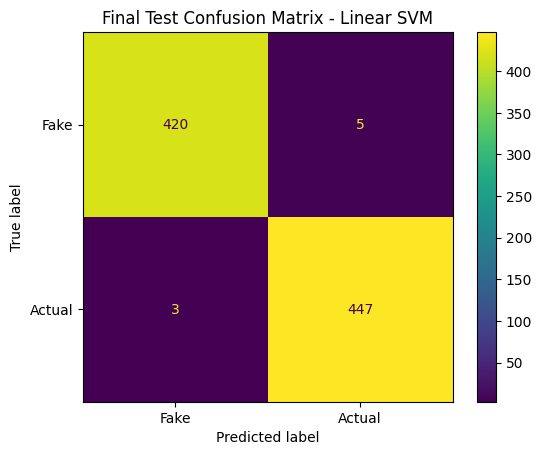

In [70]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Fake", "Actual"],
    values_format="d"
)

plt.title(
    "Final Test Confusion Matrix - Linear SVM"
)

plt.show()

Inspección final de features, para comprobar que el comportamiento se mantiene:

In [71]:
final_top_fake, final_top_actual = (
    get_top_features(
        final_pipeline
    )
)

display(final_top_fake)
display(final_top_actual)

,feature,coefficient
0,video,-2.491670
1,president trump,-2.025563
2,gop,-1.828823
3,read,-1.824001
4,just,-1.816701
5,breaking,-1.687311
6,hillary,-1.667193
7,featured,-1.656241
8,featured image,-1.612409
9,america,-1.605277


,feature,coefficient
0,reuters,7.585767
1,said,5.268726
2,washington reuters,3.073279
3,president donald,2.066018
4,tuesday,1.596564
5,republican,1.586255
6,reuters president,1.529044
7,washington,1.511944
8,wednesday,1.476861
9,thursday,1.473737


El modelo no está aprendiendo “verdad vs falsedad” de forma pura; está aprovechando patrones léxicos, temáticos, de formato y de procedencia que están correlacionados con las etiquetas en este corpus.

#### Artefactos:

In [73]:
ARTIFACT_DIR = Path(
    "../Artefactos"
)

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [75]:
joblib.dump(
    final_pipeline,
    ARTIFACT_DIR
    / "fake_news_pipeline.joblib"
)

['..\\Artefactos\\fake_news_pipeline.joblib']

In [78]:
metadata = {
    "model_name": "LinearSVC",
    "model_version": "1.0",
    "language": "en",

    "input": {
        "fields": [
            "title",
            "text"
        ],
        "model_input": "title + text"
    },

    "labels": {
        "0": "Fake",
        "1": "Actual"
    },

    "vectorizer": {
        "type": "TfidfVectorizer",
        "lowercase": True,
        "stop_words": "english",
        "ngram_range": [1, 2],
        "min_df": 5,
        "max_df": 0.95,
        "max_features": 20000
    },

    "classifier": {
        "type": "LinearSVC",
        "C": 2
    },

    "selection_metric": "macro_f1",

    "limitations": [
        "Model performance is influenced by source-specific and editorial language patterns present in the training data.",
        "Model predictions reflect patterns learned from the training corpus and should not be interpreted as a direct measure of factual truth.",
        "The model is intended to provide an auxiliary textual classification signal within a broader evidence-based verification system."
    ]
}

In [79]:
with open(
    ARTIFACT_DIR
    / "model_metadata.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

In [80]:
metrics_artifact = {
    "validation": {
        "macro_f1": 0.987396
    },

    "reuters_ablation": {
        "original_macro_f1": 0.987396,
        "without_reuters_macro_f1": 0.980510,
        "macro_f1_drop": 0.006886
    },

    "test": {
        key: float(value)
        for key, value
        in final_test_metrics.items()
    }
}

In [81]:
with open(
    ARTIFACT_DIR
    / "metrics.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metrics_artifact,
        f,
        indent=4
    )

#### Check Artefacto:

In [82]:
loaded_pipeline = joblib.load(
    ARTIFACT_DIR
    / "fake_news_pipeline.joblib"
)

In [83]:
sample_text = X_test.iloc[0]

original_prediction = (
    final_pipeline.predict(
        [sample_text]
    )[0]
)

loaded_prediction = (
    loaded_pipeline.predict(
        [sample_text]
    )[0]
)

print(
    "Original:",
    original_prediction
)

print(
    "Loaded:",
    loaded_prediction
)

Original: 1
Loaded: 1


Debido a la elección de SVM como modelo, no tenemos predict_proba, en este caso tenemos decision_function(): <br>

* `Importante`: No es una probabilidad.

In [84]:
score = loaded_pipeline.decision_function(
    [sample_text]
)[0]

print(score)

0.6426782641699234


Interpretación:

score < 0 <br>
más hacia Fake

score > 0 <br>
más hacia Actual

|score| grande <br>
lejos de la frontera



                     TRAINING

processed_data_en.csv
        ↓
train / validation / test
        ↓
model comparison
        ↓
GridSearchCV
        ↓
Linear SVM
        ↓
shortcut ablation
        ↓
final selection
        ↓
train + validation
        ↓
FINAL TEST
        ↓
fake_news_pipeline.joblib
        │
        │
        └──────────────────────────┐
                                   ↓
                               AGENT
                                   │
                         title + article
                                   ↓
                          preprocessing.py
                                   ↓
                           build_model_text
                                   ↓
                            inference.py
                                   ↓
                 fake_news_pipeline.joblib
                                   ↓
                          prediction + score
                                   ↓
                     auxiliary ML signal